## Diabetes Risk Factor Analysis

**Purpose:** This notebook performs an exploratory and inferential analysis of a patient-level diabetes dataset to identify variables associated with a diabetes diagnosis ('Outcome'). It is intended to serve as a reproducible template that other clinical sites in our health system can adapt to their own patient data.

**How to use this notebook:**
1. Read each markdown section before running the code beneath it.
2. Run cells **in order, top to bottom** (Runtime -> Restart session and run all).
3. Do not skip the "Setup and Environment" or "Data Source" sections as later cells depend on variables created there.

See the accompanying 'README.md' for full setup instructions, dataset requirements, and expected outputs.

## 1. Setup and Environment

This notebook was developed and tested in **Google Colab** using **Python 3.10+**. It will also run in a local Jupyter Notebook or VS Code environment, provided the packages below are installed.

### Required packages

| Package     | Tested version | Purpose                              |
|-------------|----------------|---------------------------------------|
| pandas      | 2.x            | data loading, manipulation            |
| numpy       | 1.26.x         | numerical operations, random seeding  |
| matplotlib  | 3.x            | visualizations                        |
| scipy       | 1.11.x         | inferential statistics (t-test, chi-square) |


If any package is missing, run the cell below once. Google Colab already
includes all of these packages, so this step is mainly for local installations.

In [20]:
#Run this cell once if a package is missing (safe to run even if already installed).
#Uncomment the line below if running locally and a package is not found.
#!pip install pandas>=2.0 numpy>=1.26 matplotlib>=3.7 scipy>=1.11

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#Print versions so results can be traced back to a specific environment.
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("scipy version:", stats.__name__ and __import__("scipy").__version__)

pandas version: 2.2.3
numpy version: 2.1.3
scipy version: 1.16.3


## Reproducibility Seed

Fix all sources of randomness up front.
This ensures that any random sampling, shuffling, or future
train/test splitting produces identical results every time
the notebook is run, including after "Restart session and run all".

In [21]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Data Source

**Dataset:** Example Diabetes Dataset (patient-level clinical measurements)

**Provenance:** This dataset is a commonly used diabetes screening dataset
(based on the structure of the Pima Indians Diabetes Database) containing 768
de-identified patient records and 8 clinical predictor variables plus a binary
outcome variable:

| Column | Description |
|---|---|
| Pregnancies | Number of prior pregnancies |
| Glucose | Plasma glucose concentration (mg/dL) |
| D_BP | Diastolic blood pressure (mm Hg) |
| Skin_Thickness | Triceps skinfold thickness (mm) |
| Insulin | 2-hour serum insulin (mu U/mL) |
| BMI | Body mass index (kg/m²) |
| Pedigree | Genetic/familial diabetes risk score |
| Age | Age in years |
| Outcome | 0 = no diabetes, 1 = diabetes |

**Known data quality issue:** In this dataset, physiologically impossible zero
values (e.g., `Glucose = 0`, `BMI = 0`) are used as placeholders for missing
data rather than `NaN`. This is addressed in the Initial Data Review section
below.

### How to obtain and load the dataset
1. Download `Example Dataset_Diabetes.csv` from the course GitHub repository's
   `/data` folder.
2. Upload the file into the **same folder as this notebook** (in Colab: use
   the file browser on the left, or run `files.upload()` if prompted).
3. Do **not** rename the file.

The cell below loads the dataset using a **relative path** so it works in any
environment (Colab, local Jupyter, VS Code) as long as the CSV is in the same
directory as the notebook.

In [22]:
import os

DATA_FILE = "Example Dataset_Diabetes.csv"

def load_dataset(filename):
    """
    Load the diabetes dataset from a relative path.
    Raises a clear error if the file cannot be found, instead of
    failing with a confusing traceback.
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Could not find '{filename}' in the current working directory "
            f"({os.getcwd()}). Please upload the dataset file to this "
            f"notebook's working folder as described in the Data Source "
            f"section above."
        )
    return pd.read_csv(filename)

df = load_dataset(DATA_FILE)
df.head()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Initial Data Review

Before analyzing the data, we confirm that the file loaded correctly and
matches the expected structure. This protects against silently analyzing the
wrong file or a corrupted dataset.

In [23]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nData types:")
print(df.dtypes)

Shape: (768, 9)

Missing values:
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

Data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object


In [24]:
#Basic checks
print("Shape:", df.shape)
print("\nMissing values (NaN) per column:")
print(df.isna().sum())
print("\nData types:")
print(df.dtypes)


expected_columns = [
    "Pregnancies", "Glucose", "D_BP", "Skin_Thickness",
    "Insulin", "BMI", "Pedigree", "Age", "Outcome"
]

missing_columns = []
for col in expected_columns:
    if col not in df.columns:
        missing_columns.append(col)

if len(missing_columns) > 0:
    raise ValueError(f"Dataset is missing expected columns: {missing_columns}")
else:
    print("\nAll expected columns are present.")

#Confirm Outcome is binary (0/1) as expected for this analysis.
unique_outcomes = sorted(df["Outcome"].unique())
if unique_outcomes != [0, 1]:
    raise ValueError(f"Outcome column contains unexpected values: {unique_outcomes}")
else:
    print("Outcome column confirmed binary (0/1).")

print("\nDataset successfully validated. Proceeding with analysis.")

Shape: (768, 9)

Missing values (NaN) per column:
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

Data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object

All expected columns are present.
Outcome column confirmed binary (0/1).

Dataset successfully validated. Proceeding with analysis.


In [25]:
#Several columns use 0 as a placeholder for missing data
#(a value of 0 is not physiologically possible for these
#measurements). We replace 0 with NaN in these columns only,
#then report how much data is affected.

columns_with_zero_as_missing = ["Glucose", "D_BP", "Skin_Thickness", "Insulin", "BMI"]

df_clean = df.copy()  #work on a copy so this cell is safe to re-run
for col in columns_with_zero_as_missing:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("Missing values after treating 0 as missing:")
print(df_clean[columns_with_zero_as_missing].isna().sum())

Missing values after treating 0 as missing:
Glucose             5
D_BP               35
Skin_Thickness    227
Insulin           374
BMI                11
dtype: int64


> **Note:** `Insulin` and `Skin_Thickness` typically contain the largest number
> of placeholder zeros in this dataset. Descriptive statistics and
> visualizations below use `df_clean` so these missing values do not distort
> the results (ex: an average BMI of 0 wouldn't mean anything).

## 4. Descriptive Statistics

The table below summarizes the central tendency and spread of each clinical
variable using `df_clean.describe()`.

### Mean and Standard Deviation

The **sample mean** summarizes the average value of a clinical variable across
all patients:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

where $\bar{x}$ is the sample mean, $x_i$ is an individual patient's value,
and $n$ is the number of patients with a non-missing value.

The **sample standard deviation** describes how much patient values typically
differ from that average:

$$
s = \sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

**Interpretation specific to this dataset:**
- `Glucose` and `BMI` have standard deviations that are small relative to
  their means, indicating most patients cluster around a typical value with
  a smaller number of high-glucose or high-BMI outliers.
- `Insulin` has a standard deviation that is very large relative to its mean.
  This reflects a right-skewed distribution in which a subset of patients have
  markedly elevated insulin levels, which is clinically consistent with
  insulin resistance in patients who go on to develop diabetes.
- `Age` and `Pregnancies` are also right-skewed, since younger patients and
  patients with fewer pregnancies make up the majority of the sample.

These patterns should be interpreted alongside the histograms in the
Visualizations section below.

In [26]:
df_clean.describe()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 5. Visualizations

This section includes:
1. Univariate distributions of two key clinical variables.
2. Two bivariate visualizations examining relationships between variables,
   including one relative to the diabetes `Outcome`.
3. A correlation heatmap summarizing relationships among all numeric variables.

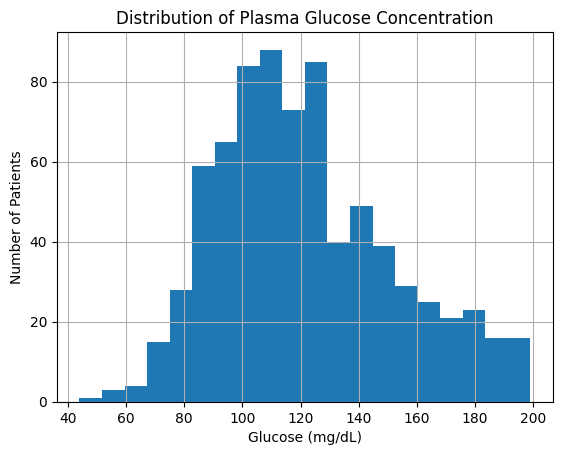

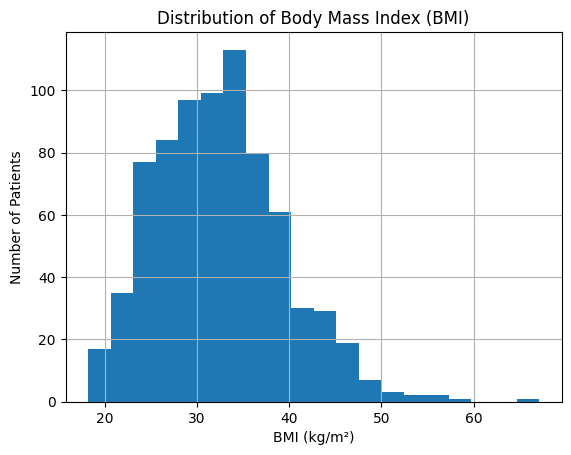

In [27]:
plt.figure()
df_clean["Glucose"].hist(bins=20)
plt.title("Distribution of Plasma Glucose Concentration")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Number of Patients")
plt.show()

plt.figure()
df_clean["BMI"].hist(bins=20)
plt.title("Distribution of Body Mass Index (BMI)")
plt.xlabel("BMI (kg/m²)")
plt.ylabel("Number of Patients")
plt.show()

<Figure size 640x480 with 0 Axes>

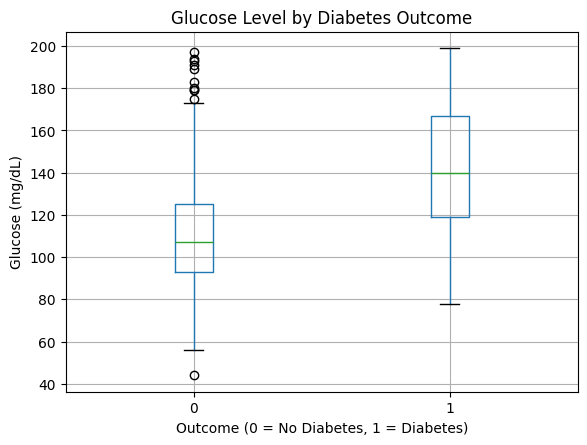

In [28]:
#Boxplot comparing Glucose levels between patients with and without diabetes
plt.figure()
df_clean.boxplot(column="Glucose", by="Outcome")
plt.title("Glucose Level by Diabetes Outcome")
plt.suptitle("")  #removes pandas subtitle
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Glucose (mg/dL)")
plt.show()

**Interpretation:** Patients with a diabetes diagnosis (`Outcome = 1`) show a
visibly higher median glucose level and a narrower spread of low values
compared to patients without diabetes. This is consistent with glucose being
a primary diagnostic marker for diabetes.

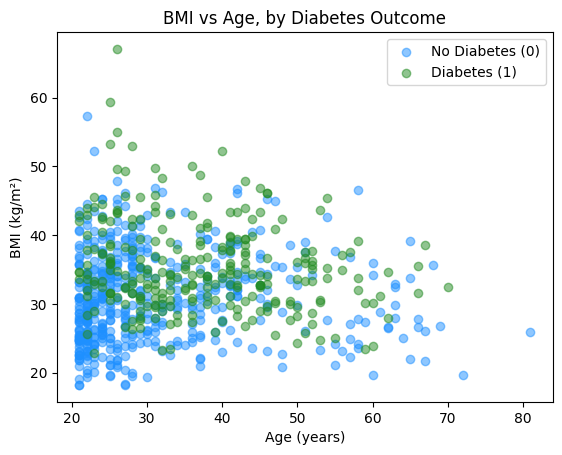

In [29]:
#Scatter plot of BMI vs Age, colored by diabetes Outcome
group_no_diabetes = df_clean[df_clean["Outcome"] == 0]
group_diabetes = df_clean[df_clean["Outcome"] == 1]

plt.figure()
plt.scatter(group_no_diabetes["Age"], group_no_diabetes["BMI"],
            alpha=0.5, color = "dodgerblue", label="No Diabetes (0)")
plt.scatter(group_diabetes["Age"], group_diabetes["BMI"],
            alpha=0.5, color = "forestgreen", label="Diabetes (1)")
plt.title("BMI vs Age, by Diabetes Outcome")
plt.xlabel("Age (years)")
plt.ylabel("BMI (kg/m²)")
plt.legend()
plt.show()

**Interpretation:** Diabetes cases (green) are visible across the full age
range, including several high-BMI outliers among younger patients
(e.g., BMI > 55 at ages 25–30). However, substantial overlap between the two
groups at every age makes it difficult to confirm a clear BMI difference from
the scatter plot alone. A summary comparison (e.g., mean BMI by outcome group,
or by age group) would provide stronger evidence than visual inspection alone
for whether BMI differs significantly between groups across the age range.

### Correlation Analysis

Several variables in this dataset (e.g., `Insulin`, `Skin_Thickness`) are
right-skewed and contain outliers even after removing placeholder zeros.
Since **Pearson correlation** assumes a linear relationship and is
sensitive to outliers, **Spearman's rank correlation** is used instead, as it
is based on ranked values and is more robust to distributions that aren't considered 'normal'.

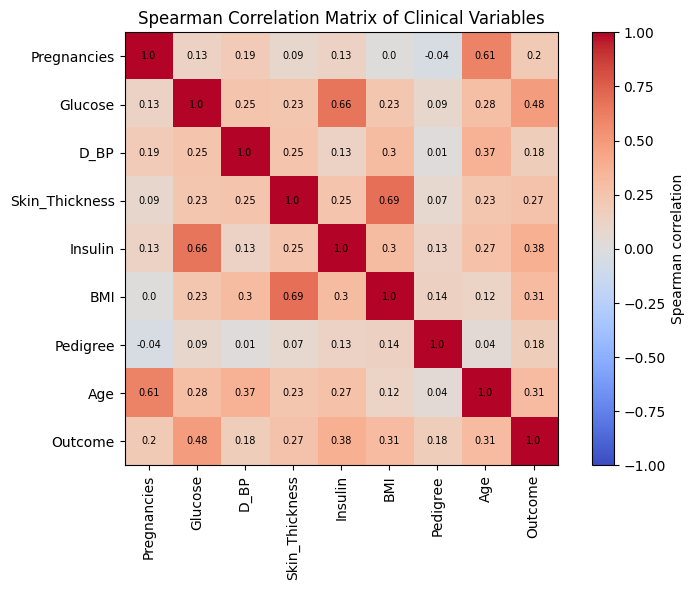

In [30]:
numeric_columns = ["Pregnancies", "Glucose", "D_BP", "Skin_Thickness",
                    "Insulin", "BMI", "Pedigree", "Age", "Outcome"]

corr_matrix = df_clean[numeric_columns].corr(method="spearman")

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(numeric_columns)), numeric_columns, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns)
plt.title("Spearman Correlation Matrix of Clinical Variables")

#Add correlation values as text labels
for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        value = round(corr_matrix.iloc[i, j], 2)
        plt.text(j, i, value, ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

**Interpretation:** `Glucose` shows the strongest positive correlation with
`Outcome` (ρ = 0.48) among all predictors, consistent with its known role as
a primary diagnostic indicator of diabetes. `Insulin` (ρ = 0.38) shows the
next-strongest relationship with `Outcome`, followed by `BMI` and `Age`
(ρ = 0.31 each); `D_BP` and `Pedigree` show the
weakest relationships with `Outcome` (ρ = 0.18).

Among predictor-to-predictor relationships, the strongest patterns in the
matrix are `BMI`–`Skin_Thickness` (ρ = 0.69) and `Glucose`–`Insulin`
(ρ = 0.66). Both are physiologically expected as BMI and skinfold thickness
are both measures of body adiposity, while glucose and insulin are directly
linked through the body's insulin response to blood sugar. `Pregnancies` and
`Age` are also strongly correlated (ρ = 0.61), which is expected since
cumulative pregnancy count naturally increases with age.

**These correlations describe association only and do not establish that
any variable causes diabetes.**

## 6. Inferential Analysis

Two inferential methods are used to evaluate whether patient characteristics
differ significantly by diabetes outcome.

### Independent Samples t-test: Glucose by Outcome

**Purpose:** Test whether mean glucose differs between patients with and
without diabetes.

$$
t = \frac{\bar{x}_1 - \bar{x}_0}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_0^2}{n_0}}}
$$

where $\bar{x}_1$ and $\bar{x}_0$ are the mean glucose values for the
diabetes and non-diabetes groups, $s_1^2$ and $s_0^2$ are their variances,
and $n_1$, $n_0$ are the respective group sizes.

In [31]:
group_0 = df_clean.loc[df_clean["Outcome"] == 0, "Glucose"].dropna()
group_1 = df_clean.loc[df_clean["Outcome"] == 1, "Glucose"].dropna()

t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)
print("t-statistic:", round(t_stat, 3))
print("p-value:", p_value)

mean_0 = group_0.mean()
mean_1 = group_1.mean()
mean_diff = mean_1 - mean_0

print("Mean Glucose (No Diabetes):", round(mean_0, 1))
print("Mean Glucose (Diabetes):", round(mean_1, 1))
print("Mean difference:", round(mean_diff, 1))

t-statistic: -14.884
p-value: 2.8439261927745043e-41
Mean Glucose (No Diabetes): 110.6
Mean Glucose (Diabetes): 142.3
Mean difference: 31.7


**Interpretation:** Patients with diabetes have a mean glucose level of
approximately 142.3 mg/dL, compared to 110.6 mg/dL for patients without diabetes, a difference of about 31.7 mg/dL. The p-value (2.8 × 10⁻⁴¹) is far below
0.05, indicating this difference is highly unlikely to be due to chance.
Given both the statistical significance and the size of the mean difference,
glucose appears to be a strong discriminating variable between outcome
groups, consistent with the boxplot above.

### Chi-Square Test of Independence: Age Group vs. Outcome

**Purpose:** Glucose and BMI are continuous variables best suited to a
t-test. To evaluate whether a **categorical** patient characteristic
(age group) is associated with diabetes outcome, we use a chi-square test of
independence.

$$
\chi^2 = \sum_{i=1}^{r}\sum_{j=1}^{c} \frac{(O_{ij}-E_{ij})^2}{E_{ij}}
$$

where $O_{ij}$ is the observed count in row $i$, column $j$ of the
contingency table, and $E_{ij}$ is the corresponding expected count under the
assumption of independence.

**What it evaluates:** Whether the distribution of diabetes outcome differs
across age groups more than would be expected by chance.

In [32]:
#Create age groups
age_bins = [0, 30, 45, 60, 120]
age_labels = ["<30", "30-44", "45-59", "60+"]
df_clean["AgeGroup"] = pd.cut(df_clean["Age"], bins=age_bins, labels=age_labels, right=False)

contingency_table = pd.crosstab(df_clean["AgeGroup"], df_clean["Outcome"])
print(contingency_table)

chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print("\nChi-square statistic:", round(chi2_stat, 3))
print("Degrees of freedom:", dof)
print("p-value:", p_value_chi2)

Outcome     0    1
AgeGroup          
<30       312   84
30-44     121  118
45-59      44   57
60+        23    9

Chi-square statistic: 75.957
Degrees of freedom: 3
p-value: 2.259669092148849e-16


**Interpretation:** The chi-square result is statistically significant
(χ² = 75.96, p < 0.001), indicating that diabetes prevalence differs across
age groups in this dataset. However, the relationship is not a simple
"older = higher risk" pattern: prevalence rises sharply from 21.2% in
patients under 30 to 49.4% in the 30-44 group and peaks at 56.4% in the
45-59 group, before declining to 28.1% in patients 60 and older. The 60+
group also contains far fewer patients (n = 32) than the other groups,
so this estimate should be interpreted cautiously. As with the correlation
analysis, this result reflects an association between age group and
diabetes outcome, not a causal relationship.


## 7. Data, Statistics, and the Machine Learning Workflow

### Formalizing the Statistical and Machine Learning Problem

We represent this dataset as:

$$
D = \{(x_i, y_i)\}_{i=1}^{n}, \quad x_i \in \mathbb{R}^{8}, \quad y_i \in \{0,1\}
$$

where:
- $D$ is the diabetes dataset used in this notebook.
- $n = 768$ is the number of patient records.
- $x_i$ is the feature vector of clinical measurements for patient $i$.
- $y_i$ is the diabetes outcome for patient $i$ (0 = no diabetes, 1 = diabetes).

For this dataset, each patient's feature vector is:

$$
x_i =
\begin{bmatrix}
\text{Pregnancies} \\
\text{Glucose} \\
\text{D_BP} \\
\text{Skin_Thickness} \\
\text{Insulin} \\
\text{BMI} \\
\text{Pedigree} \\
\text{Age}
\end{bmatrix},
\qquad
y_i = \text{Outcome}
$$

so $p = 8$ predictor variables are used to predict the binary outcome.

A supervised learning algorithm estimates a prediction function:

$$
\hat{f}: \mathbb{R}^{8} \rightarrow \{0,1\}
$$

that maps a patient's eight clinical measurements to a predicted diabetes
outcome. The goal is for $\hat{f}$ to generalize accurately to **new patients**
not used during training, which is the focus of Week 3 (building, training, and evaluating $\hat{f}$ using this same dataset structure).

## 8. Reproducibility Check

Two issues previously caused inconsistent results across executions:

1. **No fixed random seed** — resolved in Section 1 by setting
   `np.random.seed(42)` before any analysis.
2. **Results changing when cells are re-run** — earlier versions of this
   notebook modified `df` directly, so running a cell more than once (or out
   of order) produced different results each time depending on how many
   times it had already been executed. This has been resolved by:
   - Creating `df_clean` as a copy of the original data instead of
     overwriting `df`.
   - Making sure every transformation cell can be re-run safely without
     depending on how many times it was run before.

The check below confirms that a key statistic is identical across two
independent recalculations within the same session.

In [33]:
mean_glucose_first_run = df_clean["Glucose"].mean()
mean_glucose_second_run = df_clean["Glucose"].mean()

print("First calculation:", mean_glucose_first_run)
print("Second calculation:", mean_glucose_second_run)

if mean_glucose_first_run == mean_glucose_second_run:
    print("Reproducibility check passed: results are consistent.")
else:
    print("Reproducibility check FAILED: investigate non-deterministic steps.")

First calculation: 121.6867627785059
Second calculation: 121.6867627785059
Reproducibility check passed: results are consistent.


## 9. Results and Conclusions

**Summary of findings:**
- `Glucose` shows the strongest relationship with diabetes outcome, both in
  the t-test (statistically significant mean difference) and in the Spearman
  correlation analysis (ρ = 0.48).
- `Insulin` (ρ = 0.38), `BMI` (ρ = 0.31), and `Age` (ρ = 0.31) show moderate
  positive associations with diabetes outcome.
- Diabetes prevalence differs significantly across age groups (chi-square
  test, p < 0.001), but the relationship is not linear: prevalence rises
  from 21.2% (under 30) to a peak of 56.4% in the 45-59 group, then declines
  to 28.1% in patients 60 and older. The 60+ group is also the smallest
  (n = 32), so this estimate should be interpreted cautiously.
- `Insulin` and `Skin_Thickness` contain a substantial number of placeholder
  zero values that were treated as missing data prior to analysis; findings
  involving these variables should be interpreted with awareness of reduced
  sample size.
- All reported relationships are **associations**, not evidence of causation.

**Limitations:**
- This dataset represents a single population and may not generalize to
  other patient populations without local validation.
- Missing data handling (zero-replacement) removes rather than imputes
  missing values; a future iteration could evaluate imputation methods.
- No predictive model has yet been trained; this notebook establishes an
  exploratory and inferential foundation.

**Assumptions:**
- The dataset provided (`Example Dataset_Diabetes.csv`) matches the outline
  described in the Data Source section.
- Users execute this notebook top-to-bottom in a fresh runtime, per the
  instructions in Section 1.